### Build a Basic Chatbot with Langgraph(GRAPH API)

In [15]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [16]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # in this case, it appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]



In [4]:
import os
from dotenv import load_dotenv
load_dotenv()
Groq_API_KEY=os.environ["GROQ_API_KEY"]

python-dotenv could not parse statement starting at line 1


In [5]:
from langchain_groq import ChatGroq

from langchain.chat_models import init_chat_model

# llm=ChatGroq(model="llama3-8b-8192")

In [7]:
llm = init_chat_model("groq:qwen/qwen3.6-27b")

response = llm.invoke("What is the date today? and why it's a special day for india?")
response.content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Question 1: "What is the date today?"\n   - Question 2: "why it\'s a special day for india?"\n\n2.  **Identify Key Constraints/Context:**\n   - I need to provide today\'s date. Since I\'m an AI without real-time capabilities, I should check my system prompt or knowledge cutoff. The system prompt says "Current time: 2026. Knowledge cutoff: 2026." But it doesn\'t give a specific month/day. I should state that I don\'t have real-time access to the current date, but I can help if they provide it, OR I can note that as an AI I don\'t have live date tracking, but I can answer based on the date they\'re referring to.\n   - However, many AI systems are configured to know the current date if provided by the system. Since it\'s not explicitly given, I should be honest about my limitations regarding real-time data, but I can also ask for clarification or explain how to check.\n   - Wait, the prompt says "Current time: 20

In [8]:
graph_builder = StateGraph(State)

In [18]:
## Node functionality

def chatbot(state: State):
    return {"messages":[llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot) # Node name, function

## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## Compile the graph
graph = graph_builder.compile()

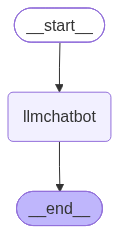

In [25]:
## Visualize the graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Hey")


In [30]:
response = graph.invoke({"messages":"Hi"})

In [33]:
response["messages"][-1].content

'\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:** The user said "Hi". This is a simple greeting.\n2.  **Identify Intent:** The user is initiating a conversation. No specific question or request is made.\n3.  **Determine Response Strategy:** \n   - Acknowledge the greeting warmly\n   - Keep it open-ended to encourage further interaction\n   - Maintain a friendly, helpful tone\n   - Match the simplicity of the input\n4.  **Draft Response (Mental):** "Hello! How can I help you today?" or "Hi there! What\'s on your mind?" or "Hello! How can I assist you?"\n5.  **Refine Response:** Keep it concise and welcoming. "Hello! How can I help you today?" is standard, effective, and open-ended.\n6.  **Final Output Generation:** Match the refined response.✅\n</think>\n\nHello! How can I help you today? 😊'

In [35]:
for event in graph.stream({"messages":"Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi how are you"\n   - This is a standard greeting and a common conversational opener.\n   - It\'s informal and friendly.\n\n2.  **Identify Key Elements:**\n   - Greeting: "Hi"\n   - Question: "how are you"\n   - Expected response: Acknowledge greeting, respond to the question politely, and invite further conversation.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the greeting warmly\n   - State that I\'m doing well (as an AI, I don\'t have feelings, but I can phrase it appropriately)\n   - Ask how they\'re doing\n   - Offer assistance\n   - Keep it concise and friendly\n\n4.  **Draft Response (Mental):**\n   Hi! I\'m doing well, thank you for asking. How are you doing today? Is there anything I can help you with?\n\n5.  **Refine Response:**\n   - Check tone: Friendly, professional, helpful\n   - Check accuracy: Acknowledge AI nature implici